# SVI Diagnostics: KELT-20b Transmission (T23)

This notebook **runs** the SVI retrieval and then performs diagnostics — all in one place.

## Workflow
1. Configure retrieval parameters (planet, epoch, species, SVI hyperparameters)
2. Run SVI directly (or load a previous run)
3. Inspect losses, guide parameters, and initialization values
4. Run likelihood diagnostics: Kp-dRV surface, processed-trail comparison, injection recovery, multi-seed SVI

Set `RUN_SVI_FRESH = True` to run SVI from scratch, or `False` to load from a saved run directory.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

try:
    import pandas as pd
except Exception:
    pd = None

plt.style.use('default')

# Find repo root
_candidate_roots = [Path.cwd(), Path.cwd().parent]

for _root in _candidate_roots:
    if (_root / 'pipeline').is_dir() and (_root / 'config').is_dir():
        REPO_ROOT = _root
        if str(REPO_ROOT) not in sys.path:
            sys.path.insert(0, str(REPO_ROOT))
        break
else:
    raise FileNotFoundError('Could not locate repo root containing pipeline/ and config/')

print(f'Repo root: {REPO_ROOT}')

Repo root: /home/calder/code/atmo-retrieval


## Retrieval Configuration

Edit the parameters below to configure the SVI run. These mirror the CLI flags from `atmo_retrieval.py`.

In [2]:
# ── Toggle: run SVI fresh or load from a previous run ──
RUN_SVI_FRESH = True

# If RUN_SVI_FRESH is False, set this to the saved run directory:
SAVED_RUN_DIR = Path("output/kelt20b/Duck24/transmission/2026-04-02_00-44-30")

# ── Target ──
PLANET = "KELT-20b"
EPHEMERIS = "Duck24"
EPOCH = "20190504"
MODE = "transmission"

# ── Model ──
PT_PROFILE = "guillot"
CHEMISTRY_MODEL = "constant"

# ── Spectral setup ──
OBSERVING_MODE = "blue"
RESOLUTION_MODE = "hr"
NLAYER = 12
N_SPECTRAL_POINTS = 60_000

# ── Species ──
ATOMS = ["Fe I"]        # Set to None for all atoms
MOLECULES = []           # Set to None for all molecules, [] for none

# ── SVI hyperparameters ──
SVI_NUM_STEPS = 1_000
SVI_LEARNING_RATE = 0.001
SVI_LR_DECAY_STEPS = 2000
SVI_LR_DECAY_RATE = 0.5
SEED = 42

# -- Optional comparison run: disable SYSREM --
ENABLE_NO_SYSREM_COMPARISON = True

# If ENABLE_NO_SYSREM_COMPARISON is True:
# - set RUN_SVI_FRESH_NO_SYSREM = True to launch a fresh no-SYSREM SVI run
# - set it to False to load an existing no-SYSREM run from SAVED_RUN_DIR_NO_SYSREM
RUN_SVI_FRESH_NO_SYSREM = True
SAVED_RUN_DIR_NO_SYSREM = Path("output/kelt20b/Duck24/transmission/SET_IF_LOADING_NO_SYSREM")


print("Configuration set.")

Configuration set.


## Run SVI (or Load Saved Run)

The cells below first resolve the SYSREM-enabled SVI run, then optionally resolve a second no-SYSREM comparison run.

When `RUN_SVI_FRESH = True`, the SYSREM cell:
1. Applies runtime config overrides
2. Calls `run_retrieval(svi_only=True)` which handles data loading, opacity setup, model building, and SVI
3. Saves all outputs to a new timestamped directory

When `RUN_SVI_FRESH = False`, it loads the SYSREM artifacts from `SAVED_RUN_DIR`.

If `ENABLE_NO_SYSREM_COMPARISON = True`, the next cell repeats the same logic with `APPLY_SYSREM_DEFAULT = False`.

In [3]:
import config as cfg

from copy import deepcopy
from pathlib import Path
from pipeline.retrieval import run_retrieval

_BASE_ATOMIC_SPECIES = deepcopy(cfg.ATOMIC_SPECIES)
_BASE_MOLPATH_HITEMP = deepcopy(cfg.MOLPATH_HITEMP)
_BASE_MOLPATH_EXOMOL = deepcopy(cfg.MOLPATH_EXOMOL)


def _resolve_saved_run_dir(saved_run_dir: Path) -> Path:
    for _root in [Path.cwd(), Path.cwd().parent]:
        candidate = _root / saved_run_dir
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find run directory: {saved_run_dir}")


def _apply_runtime_overrides(*, apply_sysrem: bool) -> None:
    cfg.set_runtime_config("PLANET", PLANET)
    cfg.set_runtime_config("EPHEMERIS", EPHEMERIS)
    cfg.set_runtime_config("RETRIEVAL_MODE", MODE)
    cfg.set_runtime_config("OBSERVING_MODE", OBSERVING_MODE)
    cfg.set_runtime_config("RESOLUTION_MODE", RESOLUTION_MODE)
    cfg.set_runtime_config("NLAYER", NLAYER)
    cfg.set_runtime_config("N_SPECTRAL_POINTS", N_SPECTRAL_POINTS)
    cfg.set_runtime_config("APPLY_SYSREM_DEFAULT", apply_sysrem)

    cfg.set_runtime_config("SVI_NUM_STEPS", SVI_NUM_STEPS)
    cfg.set_runtime_config("SVI_LEARNING_RATE", SVI_LEARNING_RATE)
    cfg.set_runtime_config("SVI_LR_DECAY_STEPS", SVI_LR_DECAY_STEPS)
    cfg.set_runtime_config("SVI_LR_DECAY_RATE", SVI_LR_DECAY_RATE)
    cfg.set_runtime_config("OPA_LOAD", True)
    cfg.set_runtime_config("DIR_SAVE", str(cfg.get_output_dir()))
    cfg.set_runtime_config("DATA_DIR", str(cfg.get_data_dir(epoch=EPOCH)))
    cfg.set_runtime_config("TRANSMISSION_DATA", cfg.get_transmission_paths(epoch=EPOCH))
    cfg.set_runtime_config("EMISSION_DATA", cfg.get_emission_paths(epoch=EPOCH))

    # Reset full species dictionaries before filtering so repeated calls stay stable.
    cfg.set_runtime_config("ATOMIC_SPECIES", deepcopy(_BASE_ATOMIC_SPECIES))
    cfg.set_runtime_config("MOLPATH_HITEMP", deepcopy(_BASE_MOLPATH_HITEMP))
    cfg.set_runtime_config("MOLPATH_EXOMOL", deepcopy(_BASE_MOLPATH_EXOMOL))

    if ATOMS is not None:
        atoms_set = set(ATOMS)
        cfg.set_runtime_config(
            "ATOMIC_SPECIES",
            {k: v for k, v in _BASE_ATOMIC_SPECIES.items() if k in atoms_set},
        )

    if MOLECULES is not None:
        mols_set = set(MOLECULES)
        cfg.set_runtime_config(
            "MOLPATH_HITEMP",
            {k: v for k, v in _BASE_MOLPATH_HITEMP.items() if k in mols_set},
        )
        cfg.set_runtime_config(
            "MOLPATH_EXOMOL",
            {k: v for k, v in _BASE_MOLPATH_EXOMOL.items() if k in mols_set},
        )


def _run_or_load_svi_case(
    *,
    run_fresh: bool,
    saved_run_dir: Path,
    apply_sysrem: bool,
    label: str,
) -> Path:
    _apply_runtime_overrides(apply_sysrem=apply_sysrem)

    if run_fresh:
        run_retrieval(
            mode=MODE,
            epoch=EPOCH,
            data_format="timeseries",
            skip_svi=False,
            svi_only=True,
            no_plots=False,
            pt_profile=PT_PROFILE,
            phase_mode="global",
            chemistry_model=CHEMISTRY_MODEL,
            seed=SEED,
        )

        output_base = Path(cfg.DIR_SAVE)
        timestamped_dirs = sorted(
            [d for d in output_base.iterdir() if d.is_dir() and (d / "svi_losses.npy").exists()],
            key=lambda d: d.stat().st_mtime,
        )
        run_dir = timestamped_dirs[-1] if timestamped_dirs else output_base
        print(f"{label} SVI run complete. Output saved to: {run_dir}")
        return run_dir

    run_dir = _resolve_saved_run_dir(saved_run_dir)
    print(f"Loading {label} saved run from: {run_dir}")
    return run_dir


/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/database/vald/api.py:29: FutureWarning: moldb module will be renenamed to adb in future.
  warnings.warn("moldb module will be renenamed to adb in future.", FutureWarning)


In [4]:
RUN_DIR_SYSREM = _run_or_load_svi_case(
    run_fresh=RUN_SVI_FRESH,
    saved_run_dir=SAVED_RUN_DIR,
    apply_sysrem=True,
    label="SYSREM",
)

# Keep downstream notebook behavior unchanged.
RUN_DIR = RUN_DIR_SYSREM

RUN_DIR



Output directory: /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-34-19
Run configuration saved to /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-34-19/run_config.log

Target: KELT-20b (Duck24)

[1/7] Loading time-series data...
  Using epoch: 20190504
  Loaded 16 exposures x 67710 wavelengths
  Phase range: -0.020 - 0.019
  Loaded SYSREM auxiliaries: chunked SYSREM: 1 chunks, chunk_sizes=[67710], basis_counts=[1]
  Wavelength range: 4746.0 - 5426.2 Angstroms
  Step 1/7 completed in 0.03s

[2/7] Setting up instrumental resolution...
  Instrument resolving power: R = 130000
  Step 2/7 completed in 0.00s

[3/7] Building wavenumber grid...
xsmode =  premodit
xsmode assumes ESLOG in wavenumber space: xsmode=premodit
Your wavelength grid is in ***  descending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
Wavenumber grid: R≈348860


/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=348859.76505614154
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=348859.76505614154
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:249: UserWarning: Resolution may be too small.

  Spectral operators initialized
  Step 3/7 completed in 0.75s

[4/7] Initializing primary atmospheric RT...
integration:  simpson
Simpson integration, uses the chord optical depth at the lower boundary and midppoint of the layers.
  12 atmospheric layers
  Pressure range: 1.0e-08 - 1.0e+00 bar
  Temperature range: 1500 - 4500 K
  Step 4/7 completed in 0.05s

[5/7] Loading opacities...
H2-H2
H2-He
  Loaded 1 CIA sources
Loading HITEMP/ExoMol databases...
  Loaded 0 molecular species: []
Loading atomic line databases (Kurucz/VALD)...
  * Fe I cache miss: Cached opacity grid mismatch.; rebuilding opacity
Reading Kurucz file


/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/database/core_atom/io.py:618: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ionE = float(


  * Fe I (Kurucz)
default elower grid trange (degt) file version: 2
Robust range: 1451.7388455722698 - 4719.651925026556 K


...

/home/calder/code/atmo-retrieval/physics/model.py:299: UserWarning: 
[WARNING] Grid Under-sampling Detected!
  Instrument Resolution (R): 130000
  Physics Grid Resolution (R_grid): ~348845
  Ratio (Grid/Inst): 2.91 pixels per FWHM.
  Recommended: > 4.0 pixels per FWHM.
  Your dtau/opacity calculation might be aliased. Regenerate 'nu_grid' with higher resolution.
  warnings.warn(


  Joint model created with 1 component(s): spectroscopy
  Atmosphere regions: terminator [transmission]
  Step 6/7 completed in 0.48s

[7/7] Running Bayesian inference...
  SVI warm-up: 1000 steps, LR=0.001 with exponential decay (steps=2000, rate=0.5)


  0%|          | 0/1000 [00:00<?, ?it/s]/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/jax/_src/linear_util.py:396: UserWarning: Found vars in model but not guide: {'Rp'}
  ans = _fun(*args, **kwargs)
100%|██████████| 1000/1000 [00:35<00:00, 28.35it/s, init loss: -4795632.5000, avg. loss [951-1000]: -4795796.4000]


SVI params saved to /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-34-19/svi_params.npz
SVI losses saved to /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-34-19/svi_losses.npy
SVI init values saved to /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-34-19/svi_init_values.npz
  Generating corner plots from SVI posterior...
No posterior samples available for corner plots; skipping.
SVI loss plot saved to /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-34-19/svi_loss.png
  SVI complete (svi_only=True); skipping MCMC.
  Step 7/7 completed in 75.89s
SYSREM SVI run complete. Output saved to: /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-34-19


PosixPath('/home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-34-19')

In [5]:
RUN_DIR_NO_SYSREM = None

if ENABLE_NO_SYSREM_COMPARISON:
    RUN_DIR_NO_SYSREM = _run_or_load_svi_case(
        run_fresh=RUN_SVI_FRESH_NO_SYSREM,
        saved_run_dir=SAVED_RUN_DIR_NO_SYSREM,
        apply_sysrem=False,
        label="No-SYSREM",
    )

RUN_DIR_NO_SYSREM



Output directory: /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-36-00
Run configuration saved to /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-36-00/run_config.log

Target: KELT-20b (Duck24)

[1/7] Loading time-series data...
  Using epoch: 20190504
  Loaded 16 exposures x 67710 wavelengths
  Phase range: -0.020 - 0.019
  Wavelength range: 4746.0 - 5426.2 Angstroms
  Step 1/7 completed in 0.02s

[2/7] Setting up instrumental resolution...
  Instrument resolving power: R = 130000
  Step 2/7 completed in 0.00s

[3/7] Building wavenumber grid...
xsmode =  premodit
xsmode assumes ESLOG in wavenumber space: xsmode=premodit
Your wavelength grid is in ***  descending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
Wavenumber grid: R≈348860
  Spectral operators initialized
  Step 3/7 completed in 0.02s

[4/7] Initializing primary atmospheric RT...
int

/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=348859.76505614154
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=348859.76505614154
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:249: UserWarning: Resolution may be too small.

H2-He
  Loaded 1 CIA sources
Loading HITEMP/ExoMol databases...
  Loaded 0 molecular species: []
Loading atomic line databases (Kurucz/VALD)...
  * Fe I (cached)
  Loaded 1 atomic species: ['Fe I']
  Step 5/7 completed in 5.43s

[6/7] Building retrieval model (primary=transmission, default P-T=guillot)...
  Chemistry model: constant
  Joint model created with 1 component(s): spectroscopy
  Atmosphere regions: terminator [transmission]
  Step 6/7 completed in 0.02s

[7/7] Running Bayesian inference...
  SVI warm-up: 1000 steps, LR=0.001 with exponential decay (steps=2000, rate=0.5)


/home/calder/code/atmo-retrieval/physics/model.py:299: UserWarning: 
[WARNING] Grid Under-sampling Detected!
  Instrument Resolution (R): 130000
  Physics Grid Resolution (R_grid): ~348845
  Ratio (Grid/Inst): 2.91 pixels per FWHM.
  Recommended: > 4.0 pixels per FWHM.
  Your dtau/opacity calculation might be aliased. Regenerate 'nu_grid' with higher resolution.
  warnings.warn(
  0%|          | 0/1000 [00:00<?, ?it/s]/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/jax/_src/linear_util.py:396: UserWarning: Found vars in model but not guide: {'Rp'}
  ans = _fun(*args, **kwargs)
100%|██████████| 1000/1000 [00:34<00:00, 29.09it/s, init loss: -4795630.5000, avg. loss [951-1000]: -4795795.5600]


SVI params saved to /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-36-00/svi_params.npz
SVI losses saved to /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-36-00/svi_losses.npy
SVI init values saved to /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-36-00/svi_init_values.npz
  Generating corner plots from SVI posterior...
No posterior samples available for corner plots; skipping.
SVI loss plot saved to /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-36-00/svi_loss.png
  SVI complete (svi_only=True); skipping MCMC.
  Step 7/7 completed in 41.13s
No-SYSREM SVI run complete. Output saved to: /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-36-00


PosixPath('/home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-36-00')

---
## Inspect Saved SVI Artifacts

The first artifact cell loads the SYSREM run. If configured, the next cell loads the no-SYSREM comparison run.

Each run exposes the same four output files:
- `svi_losses.npy`
- `svi_params.npz`
- `svi_init_values.npz`
- `run_config.log`

**Note:** `svi_params.npz` contains autoguide tensors (`auto_loc`, `auto_scale_tril`), not directly named physical parameters. The named quantities in `svi_init_values.npz` are initialization values, not posterior summaries.

In [6]:
losses = np.load(RUN_DIR_SYSREM / 'svi_losses.npy')
guide_params = np.load(RUN_DIR_SYSREM / 'svi_params.npz')
init_values = np.load(RUN_DIR_SYSREM / 'svi_init_values.npz')
run_config_text = (RUN_DIR_SYSREM / 'run_config.log').read_text()

display(Markdown(f'## SYSREM Run Directory\n`{RUN_DIR_SYSREM}`'))
print(run_config_text)

## SYSREM Run Directory
`/home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-34-19`

RETRIEVAL RUN CONFIGURATION

Run started: 2026-04-02 03:34:19
Random seed: 42

SYSTEM INFORMATION
----------------------------------------------------------------------
Platform: Linux-6.14.0-37-generic-x86_64-with-glibc2.39
Python: 3.10.19
JAX version: 0.6.2
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]

TARGET
----------------------------------------------------------------------
Planet: KELT-20b
Ephemeris: Duck24
Epoch: 20190504
Period: 3.47410151
R_p: 1.741
M_p: 3.382
R_star: 1.565
T_star: 8720
Systemic velocity (fixed): -22.78

RETRIEVAL CONFIGURATION
----------------------------------------------------------------------
Mode: transmission
P-T profile: guillot
Chemistry model: constant
Output directory: /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-34-19

SPECTRAL SETUP
----------------------------------------------------------------------
Observatory: lbt
Instrument: PEPSI
Observing mode: blue
Wavelength range: 4752 - 5425 Angstroms
Spectral

In [7]:
losses_no_sysrem = None
guide_params_no_sysrem = None
init_values_no_sysrem = None
run_config_text_no_sysrem = None

if RUN_DIR_NO_SYSREM is not None:
    losses_no_sysrem = np.load(RUN_DIR_NO_SYSREM / 'svi_losses.npy')
    guide_params_no_sysrem = np.load(RUN_DIR_NO_SYSREM / 'svi_params.npz')
    init_values_no_sysrem = np.load(RUN_DIR_NO_SYSREM / 'svi_init_values.npz')
    run_config_text_no_sysrem = (RUN_DIR_NO_SYSREM / 'run_config.log').read_text()

    display(Markdown(f'## No-SYSREM Run Directory\n`{RUN_DIR_NO_SYSREM}`'))
    print(run_config_text_no_sysrem)
else:
    print('No no-SYSREM comparison run configured.')


## No-SYSREM Run Directory
`/home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-36-00`

RETRIEVAL RUN CONFIGURATION

Run started: 2026-04-02 03:36:00
Random seed: 42

SYSTEM INFORMATION
----------------------------------------------------------------------
Platform: Linux-6.14.0-37-generic-x86_64-with-glibc2.39
Python: 3.10.19
JAX version: 0.6.2
JAX backend: gpu
JAX devices: [CudaDevice(id=0)]

TARGET
----------------------------------------------------------------------
Planet: KELT-20b
Ephemeris: Duck24
Epoch: 20190504
Period: 3.47410151
R_p: 1.741
M_p: 3.382
R_star: 1.565
T_star: 8720
Systemic velocity (fixed): -22.78

RETRIEVAL CONFIGURATION
----------------------------------------------------------------------
Mode: transmission
P-T profile: guillot
Chemistry model: constant
Output directory: /home/calder/code/atmo-retrieval/output/kelt20b/Duck24/transmission/2026-04-02_03-36-00

SPECTRAL SETUP
----------------------------------------------------------------------
Observatory: lbt
Instrument: PEPSI
Observing mode: blue
Wavelength range: 4752 - 5425 Angstroms
Spectral

In [8]:
def summarize_npz(npz_file):
    rows = []
    for key in npz_file.files:
        arr = np.asarray(npz_file[key])
        rows.append({
            'name': key,
            'shape': tuple(arr.shape),
            'dtype': str(arr.dtype),
            'all_finite': bool(np.isfinite(arr).all()),
            'min': float(np.nanmin(arr)),
            'max': float(np.nanmax(arr)),
        })
    return rows

guide_summary = summarize_npz(guide_params)
init_summary = summarize_npz(init_values)

checks = {
    'losses_finite': bool(np.isfinite(losses).all()),
    'guide_params_finite': all(row['all_finite'] for row in guide_summary),
    'init_values_finite': all(row['all_finite'] for row in init_summary),
    'n_steps': int(losses.size),
}

checks

{'losses_finite': True,
 'guide_params_finite': True,
 'init_values_finite': True,
 'n_steps': 1000}

In [9]:
if pd is not None:
    display(Markdown('## `svi_params.npz` Summary'))
    display(pd.DataFrame(guide_summary))
    display(Markdown('## `svi_init_values.npz` Summary'))
    display(pd.DataFrame(init_summary))
else:
    guide_summary, init_summary

## `svi_params.npz` Summary

,name,shape,dtype,all_finite,min,max
0,auto_loc,"(6,)",float32,True,-4.834141,7.957860
1,auto_scale_tril,"(6, 6)",float32,True,-0.073372,0.217606


## `svi_init_values.npz` Summary

,name,shape,dtype,all_finite,min,max
0,Kp,(),float32,True,168.790344,168.790344
1,Tirr,(),float32,True,2857.950195,2857.950195
2,kappa_ir_cgs,(),float32,True,0.007990,0.007990
3,gamma,(),float32,True,1.687741,1.687741
4,logVMR_Fe I,(),float32,True,-5.523980,-5.523980
5,dRV,(),float32,True,4.740562,4.740562
6,Mp,(),float64,True,3.382000,3.382000
7,Rstar,(),float64,True,1.565000,1.565000


In [10]:
best_step = int(np.argmin(losses))
loss_stats = {
    'first': float(losses[0]),
    'last': float(losses[-1]),
    'best': float(losses.min()),
    'best_step': best_step,
    'first5_mean': float(losses[:5].mean()),
    'last5_mean': float(losses[-5:].mean()),
    'last10_mean': float(losses[-10:].mean()),
    'last10_std': float(losses[-10:].std()),
}
loss_stats

{'first': -4795632.5,
 'last': -4795808.5,
 'best': -4795830.5,
 'best_step': 254,
 'first5_mean': -4795747.5,
 'last5_mean': -4795814.5,
 'last10_mean': -4795814.0,
 'last10_std': 5.527205467224121}

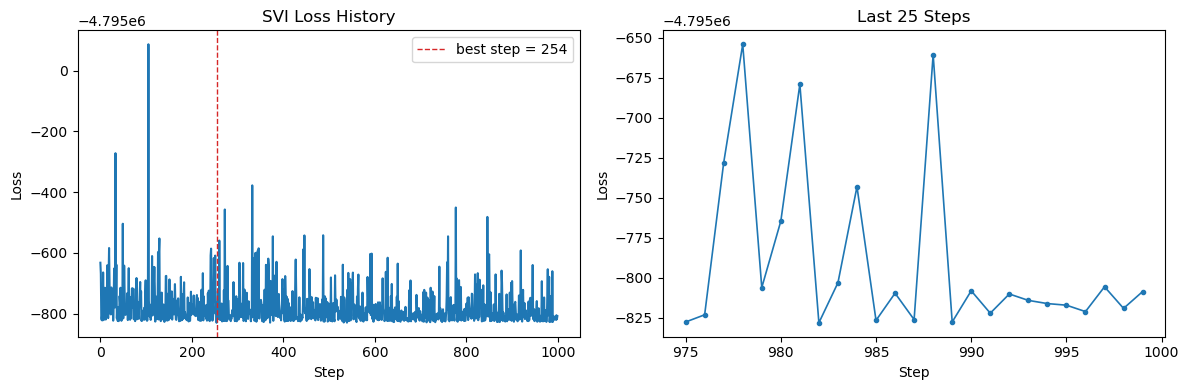

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

steps = np.arange(losses.size)
axes[0].plot(steps, losses, lw=1.5)
axes[0].axvline(best_step, color='tab:red', ls='--', lw=1, label=f'best step = {best_step}')
axes[0].set_title('SVI Loss History')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].legend()

tail_n = min(25, losses.size)
axes[1].plot(steps[-tail_n:], losses[-tail_n:], marker='o', ms=3, lw=1.2)
axes[1].set_title(f'Last {tail_n} Steps')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

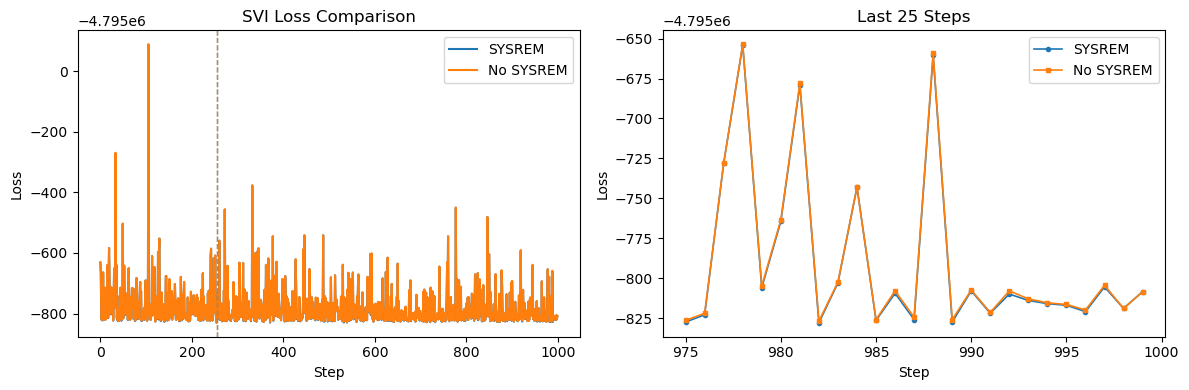

In [12]:
if losses_no_sysrem is not None:
    best_step_no_sysrem = int(np.argmin(losses_no_sysrem))
    tail_n_compare = min(25, losses.size, losses_no_sysrem.size)

    steps_sysrem = np.arange(losses.size)
    steps_no_sysrem = np.arange(losses_no_sysrem.size)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(steps_sysrem, losses, lw=1.5, label='SYSREM')
    axes[0].plot(steps_no_sysrem, losses_no_sysrem, lw=1.5, label='No SYSREM')
    axes[0].axvline(best_step, color='tab:blue', ls='--', lw=1, alpha=0.8)
    axes[0].axvline(best_step_no_sysrem, color='tab:orange', ls='--', lw=1, alpha=0.8)
    axes[0].set_title('SVI Loss Comparison')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(
        steps_sysrem[-tail_n_compare:],
        losses[-tail_n_compare:],
        marker='o',
        ms=3,
        lw=1.2,
        label='SYSREM',
    )
    axes[1].plot(
        steps_no_sysrem[-tail_n_compare:],
        losses_no_sysrem[-tail_n_compare:],
        marker='s',
        ms=3,
        lw=1.2,
        label='No SYSREM',
    )
    axes[1].set_title(f'Last {tail_n_compare} Steps')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('No no-SYSREM losses loaded.')


In [13]:
auto_loc = np.asarray(guide_params['auto_loc'])
auto_scale_tril = np.asarray(guide_params['auto_scale_tril'])
scale_diag = np.diag(auto_scale_tril)
cov = auto_scale_tril @ auto_scale_tril.T
eigvals = np.linalg.eigvalsh(cov)

guide_diagnostics = {
    'latent_dim': int(auto_loc.size),
    'auto_loc_min': float(auto_loc.min()),
    'auto_loc_max': float(auto_loc.max()),
    'scale_diag_min': float(scale_diag.min()),
    'scale_diag_max': float(scale_diag.max()),
    'cov_eig_min': float(eigvals.min()),
    'cov_eig_max': float(eigvals.max()),
}
guide_diagnostics

{'latent_dim': 6,
 'auto_loc_min': -4.834140777587891,
 'auto_loc_max': 7.957859992980957,
 'scale_diag_min': 0.06911201775074005,
 'scale_diag_max': 0.2176062911748886,
 'cov_eig_min': 0.003211356932297349,
 'cov_eig_max': 0.07003948837518692}

In [14]:
named_init = {key: np.asarray(init_values[key]).item() for key in init_values.files}

if pd is not None:
    init_df = pd.DataFrame(
        [{'parameter': k, 'value': v} for k, v in named_init.items()]
    ).sort_values('parameter', ignore_index=True)
    display(init_df)
else:
    named_init

,parameter,value
0,Kp,168.790344
1,Mp,3.382000
2,Rstar,1.565000
3,Tirr,2857.950195
4,dRV,4.740562
5,gamma,1.687741
6,kappa_ir_cgs,0.007990
7,logVMR_Fe I,-5.523980


---
## Likelihood Diagnostics

The cells below use `pipeline.diagnostics` to probe whether the current low-`Kp` / low-`Tirr` basin is a property of the processed likelihood, a preprocessing artifact, or a seed-sensitive SVI mode.

These defaults are intentionally conservative. Start with the coarse grids / short SVI probe below, then refine only if the coarse results are promising.


In [15]:
from pipeline.diagnostics import (
    build_diag_config_from_run_dir,
    build_primary_diagnostic_context,
    default_kp_drv_grids,
    load_named_init_values,
    merge_named_params,
    scan_kp_drv_surface,
    plot_kp_drv_surface,
    plot_processed_timeseries_comparison,
    run_post_sysrem_injection_recovery,
    run_multiseed_svi,
    plot_multiseed_summary,
)

DIAG_CONFIG = build_diag_config_from_run_dir(
    RUN_DIR,
    epoch=EPOCH,
)

DIAG_CONFIG


{'planet': 'KELT-20b',
 'ephemeris': 'Duck24',
 'epoch': '20190504',
 'mode': 'transmission',
 'pt_profile': 'guillot',
 'chemistry_model': 'constant',
 'observing_mode': 'blue',
 'resolution_mode': 'hr',
 'nlayer': 12,
 'n_spectral_points': 60000,
 'atoms': ['Fe I'],
 'molecules': [],
 'load_opacities': True}

In [16]:
ctx = build_primary_diagnostic_context(**DIAG_CONFIG)
base_params = merge_named_params(ctx, load_named_init_values(RUN_DIR))

base_params


/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=348859.76505614154
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=348859.76505614154
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)
/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/exojax/utils/grids.py:249: UserWarning: Resolution may be too small.

xsmode =  premodit
xsmode assumes ESLOG in wavenumber space: xsmode=premodit
Your wavelength grid is in ***  descending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.
Wavenumber grid: R≈348860
integration:  simpson
Simpson integration, uses the chord optical depth at the lower boundary and midppoint of the layers.
H2-H2
H2-He
Loading HITEMP/ExoMol databases...
Loading atomic line databases (Kurucz/VALD)...
  * Fe I (cached)


/home/calder/code/atmo-retrieval/physics/model.py:299: UserWarning: 
[WARNING] Grid Under-sampling Detected!
  Instrument Resolution (R): 130000
  Physics Grid Resolution (R_grid): ~348845
  Ratio (Grid/Inst): 2.91 pixels per FWHM.
  Recommended: > 4.0 pixels per FWHM.
  Your dtau/opacity calculation might be aliased. Regenerate 'nu_grid' with higher resolution.
  warnings.warn(


{'Kp': 168.79034423828125,
 'Mp': 3.382,
 'Rstar': 1.565,
 'Rp': 1.741,
 'dRV': 4.7405619621276855,
 'Tirr': 2857.9501953125,
 'kappa_ir_cgs': 0.007989970967173576,
 'gamma': 1.687740683555603,
 'logVMR_Fe I': -5.523980140686035}

## `Kp`-`dRV` Surface

Use a coarse grid first. If the saved retrieval has bounded `Kp`, the default grid below respects those bounds. The plotted surface uses the raw likelihood plus the retrieval prior, so values outside the allowed `Kp` range are suppressed automatically.


In [17]:
kp_grid, drv_grid = default_kp_drv_grids(
    ctx,
    num_kp=11,
    num_drv=17,
)

scan = scan_kp_drv_surface(
    ctx,
    base_params=base_params,
    kp_grid=kp_grid,
    drv_grid=drv_grid,
    include_log_prior=True,
)

scan['best_params'], scan['best_surface_value'], scan['surface_label']


({'Kp': 176.0, 'dRV': 20.0}, 4795828.449954169, 'log posterior score')

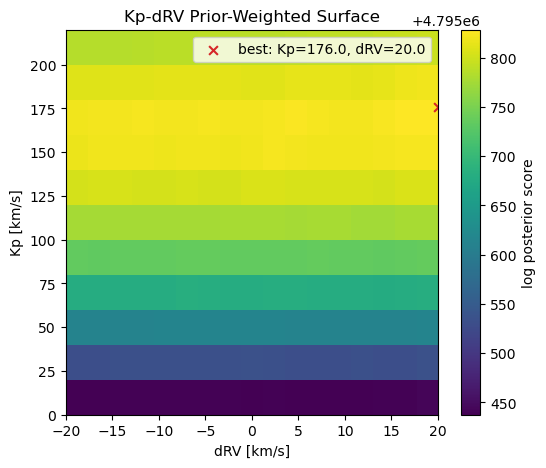

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_kp_drv_surface(scan, ax=ax)
plt.show()


## Processed Trail Comparison

Compare the processed data map against the current SVI-like solution and a literature-like velocity solution.


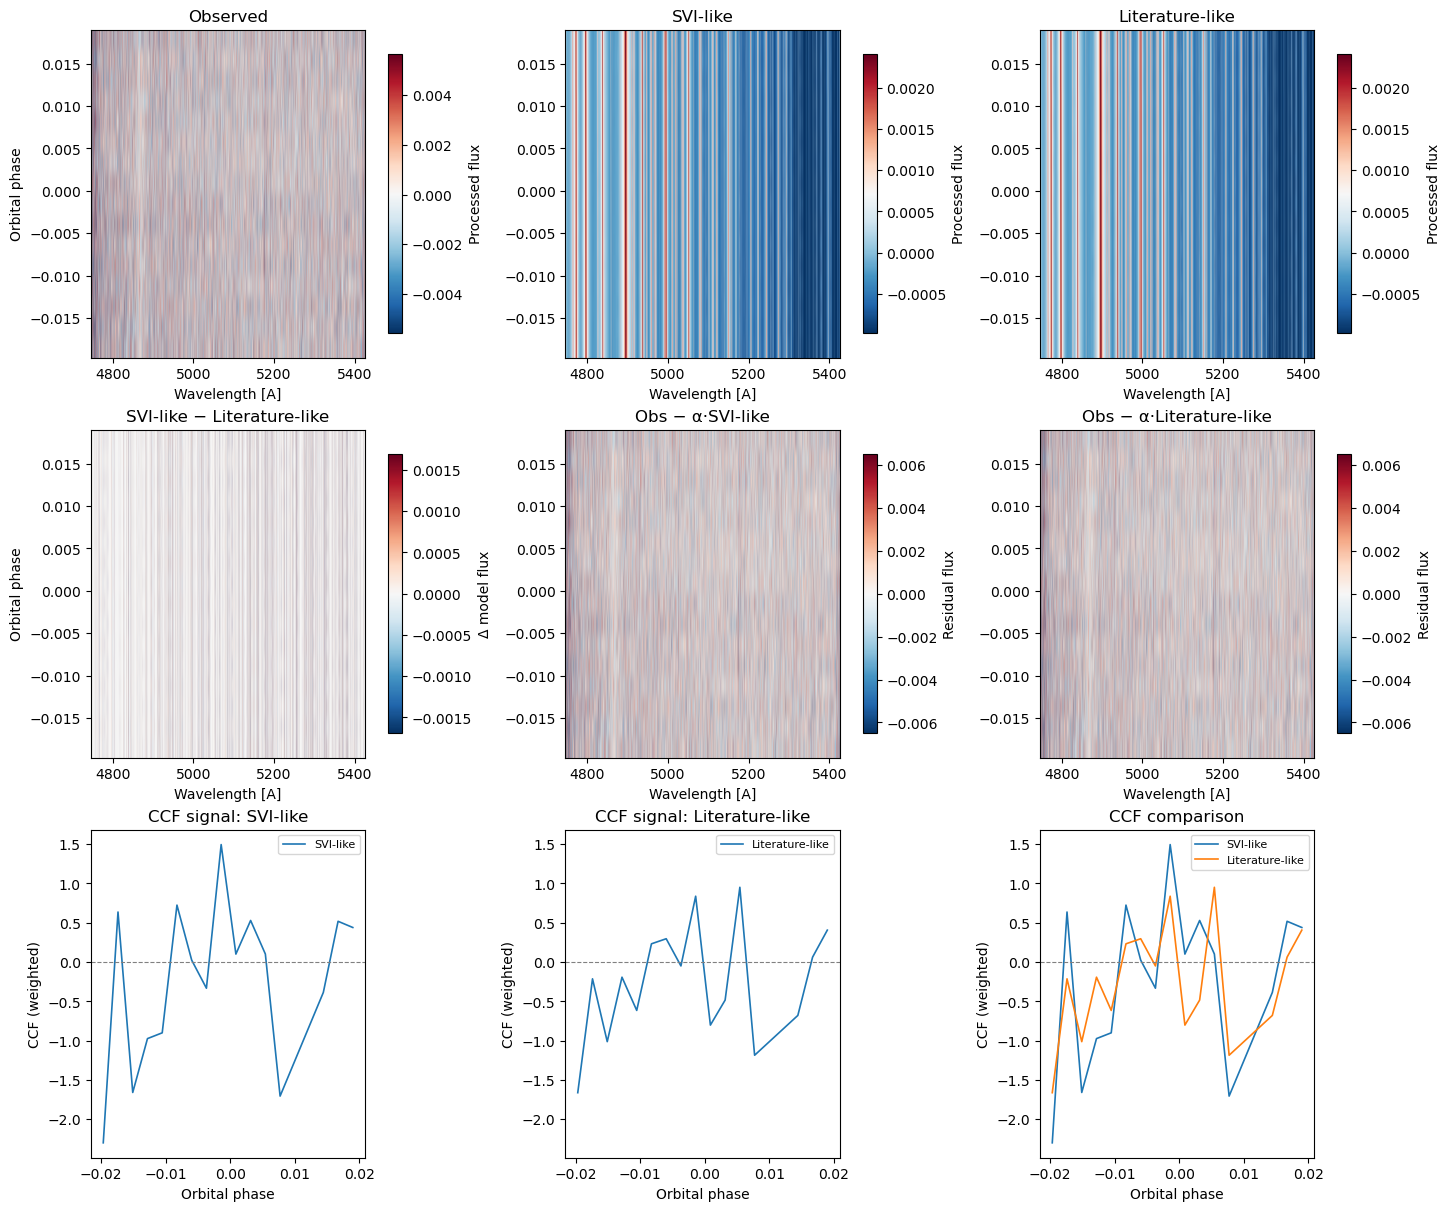

In [19]:
literature_like = dict(base_params)
literature_like['Kp'] = 169.0
literature_like['dRV'] = 0.0

fig, _ = plot_processed_timeseries_comparison(
    ctx,
    model_sets={
        'SVI-like': base_params,
        'Literature-like': literature_like,
    },
)
plt.show()


## Post-SYSREM Injection-Recovery

This injects a synthetic trail into the already SYSREM-processed timeseries, then rescans `Kp` and `dRV` on the same coarse grid.


In [20]:
inject_params = dict(base_params)
inject_params['Kp'] = 169.0
inject_params['dRV'] = 0.0

injection_scan = run_post_sysrem_injection_recovery(
    ctx,
    inject_params=inject_params,
    kp_grid=kp_grid,
    drv_grid=drv_grid,
    injection_scale=1.0,
    include_log_prior=True,
)

injection_scan['best_params'], injection_scan['best_surface_value'], injection_scan['surface_label']


({'Kp': 176.0, 'dRV': 0.0}, 4795658.8213036535, 'log posterior score')

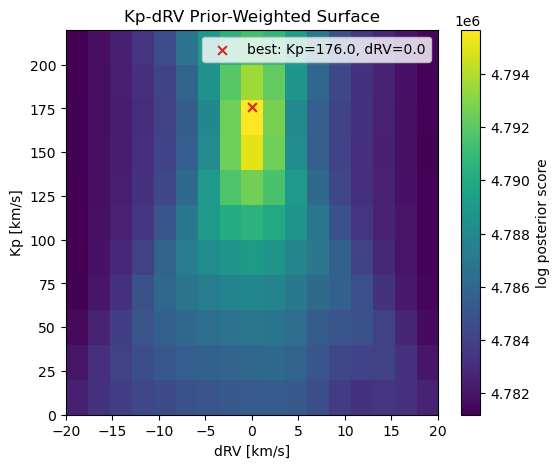

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_kp_drv_surface(injection_scan, ax=ax)
plt.show()


## Multi-Seed SVI Probe

This is a cheap seed-sensitivity check, not a production rerun. Increase the seed count / steps only if the coarse probe is informative.


In [22]:
multiseed_results = run_multiseed_svi(
    ctx,
    seeds=range(4),
    num_steps=500,
    lr=0.001,
    lr_decay_steps=2000,
    lr_decay_rate=0.5,
)

multiseed_results


  0%|          | 0/500 [00:00<?, ?it/s]/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/jax/_src/linear_util.py:396: UserWarning: Found vars in model but not guide: {'Rp'}
  ans = _fun(*args, **kwargs)
  0%|          | 0/500 [00:00<?, ?it/s]/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/jax/_src/linear_util.py:396: UserWarning: Found vars in model but not guide: {'Rp'}
  ans = _fun(*args, **kwargs)
  0%|          | 0/500 [00:00<?, ?it/s]/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/jax/_src/linear_util.py:396: UserWarning: Found vars in model but not guide: {'Rp'}
  ans = _fun(*args, **kwargs)
  0%|          | 0/500 [00:00<?, ?it/s]/home/calder/miniforge3/envs/retrieval/lib/python3.10/site-packages/jax/_src/linear_util.py:396: UserWarning: Found vars in model but not guide: {'Rp'}
  ans = _fun(*args, **kwargs)
100%|██████████| 500/500 [00:24<00:00, 20.77it/s, init loss: -4795714.0000, avg. loss [476-500]: -4795788.7000]


[{'seed': 0,
  'best_loss': -4795826.5,
  'best_step': 212,
  'final_loss': -4795795.0,
  'loss_tail_std': 40.64677047729492,
  'Kp': 164.3963165283203,
  'Tirr': 2844.162353515625,
  'gamma': 0.42705121636390686,
  'kappa_ir_cgs': 0.013587887398898602},
 {'seed': 1,
  'best_loss': -4795823.0,
  'best_step': 63,
  'final_loss': -4795819.5,
  'loss_tail_std': 133.40191650390625,
  'Kp': 168.74703979492188,
  'Tirr': 2824.898193359375,
  'gamma': 0.3169269859790802,
  'kappa_ir_cgs': 0.00456911651417613},
 {'seed': 2,
  'best_loss': -4795828.0,
  'best_step': 212,
  'final_loss': -4795817.0,
  'loss_tail_std': 79.64100646972656,
  'Kp': 168.774169921875,
  'Tirr': 2822.832275390625,
  'gamma': 0.8566622138023376,
  'kappa_ir_cgs': 0.0023477196227759123},
 {'seed': 3,
  'best_loss': -4795826.0,
  'best_step': 472,
  'final_loss': -4795821.0,
  'loss_tail_std': 35.81410217285156,
  'Kp': 168.87889099121094,
  'Tirr': 2829.66650390625,
  'gamma': 10.398759841918945,
  'kappa_ir_cgs': 0.0030

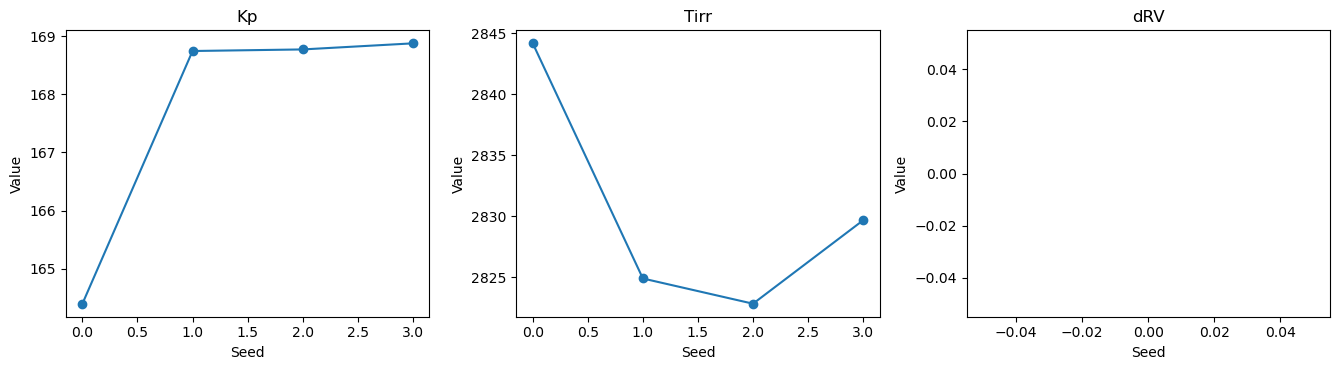

In [23]:
fig, _ = plot_multiseed_summary(
    multiseed_results,
    parameters=('Kp', 'Tirr', 'dRV'),
)
plt.show()


---
## How To Read These Diagnostics

**SVI Artifacts:**
- If `losses_finite`, `guide_params_finite`, and `init_values_finite` are all `True`, the SVI run is numerically healthy.
- A flatter tail in the loss plot is usually enough for a quick smoke test.
- `auto_loc` and `auto_scale_tril` are guide-space tensors — useful for debugging, but not directly interpretable as named atmospheric parameters.
- The named entries in `svi_init_values.npz` are initialization values used to seed inference, not posterior summaries.

**Likelihood Diagnostics:**
- If the coarse `Kp`-`dRV` map peaks near the literature `Kp`, HMC/NUTS is at least worth a short smoke test.
- If the injected post-SYSREM signal is not recovered near the injected `Kp`, the preprocessing / model pipeline is likely suppressing or distorting the moving trail.
- If the multi-seed SVI probe lands in several distinct basins with similar losses, the posterior is multimodal or poorly identified.
- If every seed lands in the same low-`Kp` basin and the injection probe also prefers low `Kp`, more inference complexity will not fix the core issue.

For the next stage, the usual move is to use this as a quick validation step and then proceed to HMC/NUTS on a scientifically acceptable spectral grid.